# Домашнее задание 7. Анализ дифференциальной экспрессии

В этой работе проводится анализ дифференциальной экспрессии генов. Цель работы — сравнить экспрессию генов между группами образцов, визуализировать структуру данных и получить списки генов, которые отличаются между группами по выбранным статистическим критериям.

Работа состоит из двух частей. В первой части анализируются RNA-seq данные методом DESeq2. Этот метод подходит для таких данных, потому что работает с сырыми целочисленными counts по генам и моделирует их с помощью отрицательного биномиального распределения. Для анализа используются таблица counts и metadata с группами образцов `R` и `NR`.

Во второй части используется отдельный набор данных `GSE63885`, представленный как матрица экспрессии микрочипового эксперимента и таблица аннотации образцов. Для него выбран LIMMA, так как этот метод хорошо подходит для анализа микрочиповой экспрессии: он сравнивает группы образцов с помощью линейных моделей и позволяет находить гены с различающейся экспрессией.

В ходе работы строятся PCA, clustermap, volcano plot, таблицы результатов дифференциальной экспрессии, а также сравнивается, как разные пороги `logFC` влияют на количество отобранных генов.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("report", exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11

import warnings
warnings.filterwarnings("ignore")

In [2]:
raw_counts = pd.read_csv("data/raw_counts_ici_samples.tsv", sep="\t", index_col=0)
meta = pd.read_csv("data/meta_responses.tsv", sep="\t", header=None, names=["sample", "response"])

print("Размер таблицы raw_counts:", raw_counts.shape)
print("Размер таблицы meta:", meta.shape)

print("\nПервые строки meta:")
display(meta.head())

print("\nКоличество образцов по группам:")
display(meta["response"].value_counts())

print("\nПервые строки raw_counts:")
display(raw_counts.head())

Размер таблицы raw_counts: (58233, 61)
Размер таблицы meta: (62, 2)

Первые строки meta:


,sample,response
0,NaN,0
1,LuC-136_S6_ME_L001_R1_001ReadsPerGene,NR
2,LuC-128_S14_ME_L001_R1_001ReadsPerGene,R
3,LuC-95_S5_ME_L001_R1_001ReadsPerGene,NR
4,LuC-135_S12_ME_L001_R1_001ReadsPerGene,NR



Количество образцов по группам:


response
NR    42
R     15
0      1
Name: count, dtype: int64


Первые строки raw_counts:


,LuC-136_S6_ME_L001_R1_001ReadsPerGene,LuC-128_S14_ME_L001_R1_001ReadsPerGene,LuC-95_S5_ME_L001_R1_001ReadsPerGene,LuC-135_S12_ME_L001_R1_001ReadsPerGene,LuC2_S6_L007_R1_001ReadsPerGene,LuC-84_S5_ME_L001_R1_001ReadsPerGene,Luc_65_S30_R1_001ReadsPerGene,LuC_59_S1_R1_001ReadsPerGene,LuC-98_S11_ME_L001_R1_001ReadsPerGene,LuC-80c_S10_ME_L001_R1_001ReadsPerGene,...,LuC-91_S1_ME_L001_R1_001ReadsPerGene,Luc_66_S24_R1_001ReadsPerGene,Luc_63_S22_R1_001ReadsPerGene,LuC-123_S13_ME_L001_R1_001ReadsPerGene,LuC-43_S12_R1_001ReadsPerGene,LuC-17_S8_R1_001ReadsPerGene,LuC_54_S12_R1_001ReadsPerGene,LuC_27_S10_R1_001ReadsPerGene,LuC-85_CGRNAReadsPerGene,LuC-111_S3_ME_L001_R1_001ReadsPerGene
ENSG00000223972,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000227232,0,0,0,0,0,4,0,0,0,0,...,1,0,0,2,0,0,0,0,78,0
ENSG00000278267,1,0,0,3,0,3,0,0,1,0,...,0,0,0,0,0,0,0,0,8,2
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
ENSG00000284332,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Убираем технические/пустые строки из metadata
meta = meta.dropna(subset=["sample"])
meta = meta[meta["response"].isin(["R", "NR"])].copy()

print("Размер meta после очистки:", meta.shape)

print("\nКоличество образцов по группам после очистки:")
display(meta["response"].value_counts())

print("\nПервые строки очищенной meta:")
display(meta.head())

Размер meta после очистки: (57, 2)

Количество образцов по группам после очистки:


response
NR    42
R     15
Name: count, dtype: int64


Первые строки очищенной meta:


,sample,response
1,LuC-136_S6_ME_L001_R1_001ReadsPerGene,NR
2,LuC-128_S14_ME_L001_R1_001ReadsPerGene,R
3,LuC-95_S5_ME_L001_R1_001ReadsPerGene,NR
4,LuC-135_S12_ME_L001_R1_001ReadsPerGene,NR
5,LuC2_S6_L007_R1_001ReadsPerGene,NR


In [4]:
# Проверяем совпадение образцов между raw_counts и meta
count_samples = set(raw_counts.columns)
meta_samples = set(meta["sample"])

common_samples = sorted(count_samples & meta_samples)
only_in_counts = sorted(count_samples - meta_samples)
only_in_meta = sorted(meta_samples - count_samples)

print("Образцов в raw_counts:", len(count_samples))
print("Образцов в meta:", len(meta_samples))
print("Общих образцов:", len(common_samples))

print("\nЕсть только в raw_counts:")
print(only_in_counts[:10], "..." if len(only_in_counts) > 10 else "")

print("\nЕсть только в meta:")
print(only_in_meta[:10], "..." if len(only_in_meta) > 10 else "")

Образцов в raw_counts: 61
Образцов в meta: 57
Общих образцов: 57

Есть только в raw_counts:
['LuC-100_S2_ME_L001_R1_001ReadsPerGene', 'LuC-3_S14_R1_001ReadsPerGene', 'LuC-98_S11_ME_L001_R1_001ReadsPerGene', 'LuC_69_S10_R1_001ReadsPerGene'] 

Есть только в meta:
[] 


## Загрузка и проверка данных

Для анализа DESeq2 используются RNA-seq данные по образцам LuC. Основная таблица `raw_counts_ici_samples.tsv` содержит сырые gene counts: строки соответствуют генам, а столбцы — образцам.

Файл `meta_responses.tsv` содержит информацию о группе каждого образца:

- `R` — responder, то есть образец из группы ответчиков на терапию;
- `NR` — non-responder, то есть образец из группы неответчиков.

После проверки совпадения образцов оказалось, что в таблице counts есть 61 образец, а в metadata — 57 образцов с известной группой. Для дальнейшего анализа используются только 57 общих образцов, потому что для 4 образцов нет информации о группе `R` или `NR`.

In [5]:
# Оставляем только образцы, для которых есть и counts, и metadata
common_samples = [sample for sample in meta["sample"] if sample in raw_counts.columns]

counts_for_analysis = raw_counts[common_samples].copy()
meta_for_analysis = meta.set_index("sample").loc[common_samples].copy()

print("Матрица counts для анализа:", counts_for_analysis.shape)
print("Metadata для анализа:", meta_for_analysis.shape)

print("\nГруппы в meta_for_analysis:")
display(meta_for_analysis["response"].value_counts())

# Убираем гены с очень низкой суммарной экспрессией.
# Это нужно для PCA и кластеризации, чтобы большое количество почти нулевых генов не добавляло шум.
min_total_count = 10
counts_filtered = counts_for_analysis[counts_for_analysis.sum(axis=1) >= min_total_count].copy()

print("\nПосле фильтрации низкоэкспрессируемых генов:")
print("Было генов:", counts_for_analysis.shape[0])
print("Осталось генов:", counts_filtered.shape[0])

# Для визуализации используем log2(count + 1)
log_counts = np.log2(counts_filtered + 1)

display(log_counts.iloc[:5, :5])

Матрица counts для анализа: (58233, 57)
Metadata для анализа: (57, 1)

Группы в meta_for_analysis:


response
NR    42
R     15
Name: count, dtype: int64


После фильтрации низкоэкспрессируемых генов:
Было генов: 58233
Осталось генов: 41371


,LuC-136_S6_ME_L001_R1_001ReadsPerGene,LuC-128_S14_ME_L001_R1_001ReadsPerGene,LuC-95_S5_ME_L001_R1_001ReadsPerGene,LuC-135_S12_ME_L001_R1_001ReadsPerGene,LuC2_S6_L007_R1_001ReadsPerGene
ENSG00000227232,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000278267,1.000000,0.000000,0.000000,2.000000,0.000000
ENSG00000238009,0.000000,0.000000,1.000000,3.169925,2.584963
ENSG00000268903,3.906891,5.523562,2.807355,4.584963,0.000000
ENSG00000269981,3.807355,4.392317,3.169925,5.426265,2.321928


## PCA образцов

Перед анализом дифференциальной экспрессии нужно проверить общую структуру данных. Для этого строится PCA по образцам.

Для PCA используется логарифмированная матрица `log2(count + 1)`. Такая трансформация уменьшает влияние очень больших count-значений и делает данные удобнее для визуализации.

Если образцы групп `R` и `NR` хорошо разделяются на PCA, это может говорить о различиях в профиле экспрессии между ответчиками и неответчиками. Если отдельные образцы находятся далеко от остальных, их можно рассматривать как возможные выбросы или как проявление batch effect.

PC1 объясняет 30.53% вариации
PC2 объясняет 6.65% вариации


,PC1,PC2,response
LuC-136_S6_ME_L001_R1_001ReadsPerGene,24.877645,12.446302,NR
LuC-128_S14_ME_L001_R1_001ReadsPerGene,37.777607,-19.350075,R
LuC-95_S5_ME_L001_R1_001ReadsPerGene,-15.646364,-1.218224,NR
LuC-135_S12_ME_L001_R1_001ReadsPerGene,-21.793387,1.407639,NR
LuC2_S6_L007_R1_001ReadsPerGene,-17.402274,-30.564267,NR


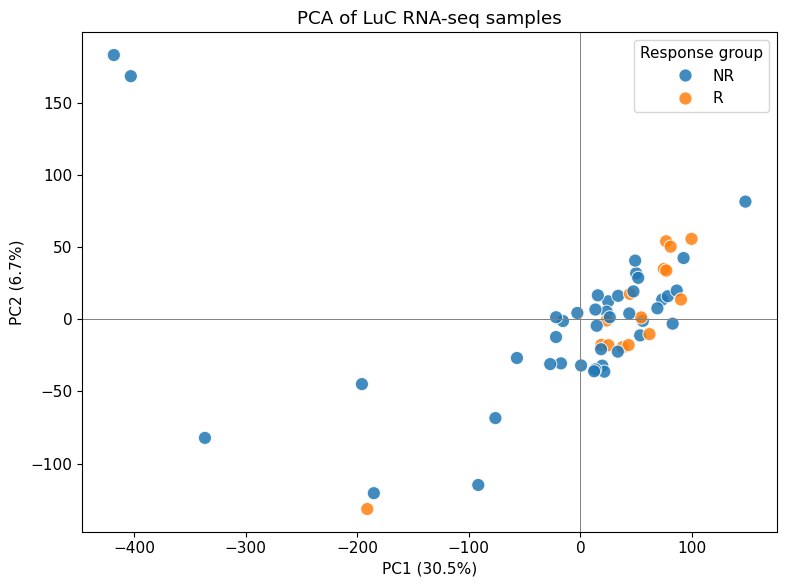

In [6]:
# PCA по образцам

# Для PCA строки должны быть образцами, а столбцы — генами
X = log_counts.T

# Масштабируем признаки, чтобы гены с большим разбросом не доминировали полностью
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_coords,
    index=X.index,
    columns=["PC1", "PC2"]
)

pca_df["response"] = meta_for_analysis.loc[pca_df.index, "response"]

explained_pc1 = pca.explained_variance_ratio_[0] * 100
explained_pc2 = pca.explained_variance_ratio_[1] * 100

print(f"PC1 объясняет {explained_pc1:.2f}% вариации")
print(f"PC2 объясняет {explained_pc2:.2f}% вариации")

display(pca_df.head())

pca_df.to_csv("results/pca_samples.tsv", sep="\t")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="response",
    s=90,
    alpha=0.85
)

plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)

plt.xlabel(f"PC1 ({explained_pc1:.1f}%)")
plt.ylabel(f"PC2 ({explained_pc2:.1f}%)")
plt.title("PCA of LuC RNA-seq samples")
plt.legend(title="Response group")
plt.tight_layout()

plt.savefig("figures/01_pca_luc_samples.png", dpi=300)
plt.show()

### Вывод по PCA

На PCA видно, что первая главная компонента объясняет около 30.5% вариации, а вторая — около 6.7%. Основная часть образцов образует общий кластер, при этом группы `R` и `NR` не разделяются полностью: часть responder и non-responder образцов располагается рядом.

Также на графике заметны несколько образцов, которые находятся далеко от основной группы точек. Такие образцы можно рассматривать как возможные выбросы или проявление batch effect. На данном этапе я не удаляю их сразу, потому что сначала нужно проверить, будут ли эти же образцы отделяться от остальных на кластеризации.

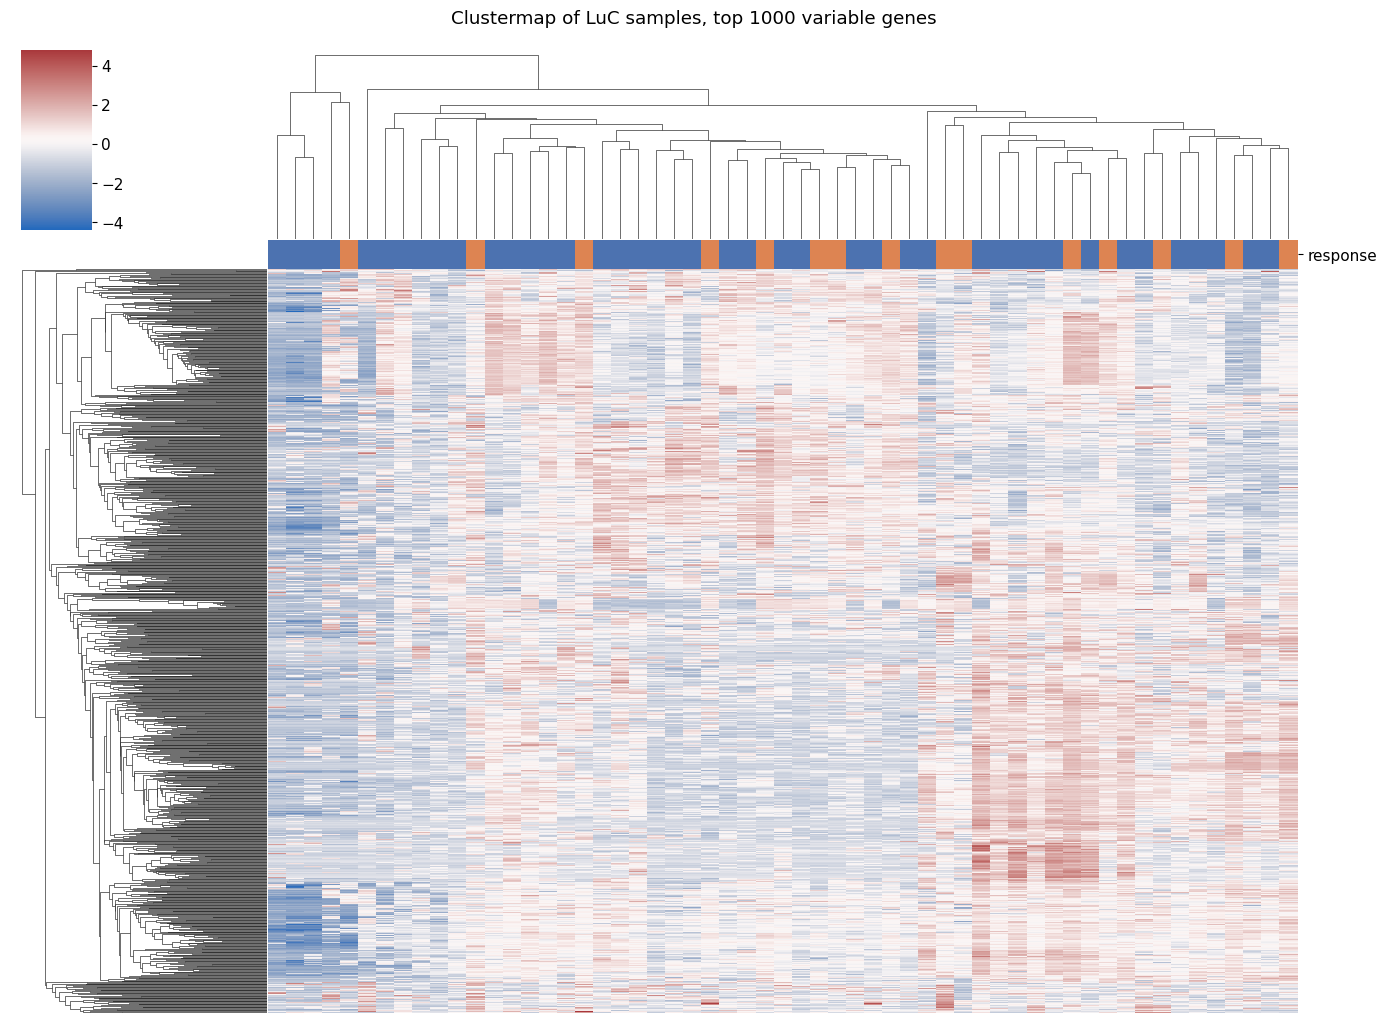

In [7]:
# Clustermap образцов

# Берём 1000 наиболее вариабельных генов, чтобы тепловая карта была информативной и не слишком тяжёлой
top_n = 1000

gene_variance = log_counts.var(axis=1).sort_values(ascending=False)
top_genes = gene_variance.head(top_n).index

clustermap_data = log_counts.loc[top_genes]

# Цветовая аннотация групп образцов
response_palette = {
    "R": "#dd8452",
    "NR": "#4c72b0"
}

col_colors = meta_for_analysis.loc[clustermap_data.columns, "response"].map(response_palette)

g = sns.clustermap(
    clustermap_data,
    z_score=0,
    cmap="vlag",
    col_colors=col_colors,
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=False
)

g.fig.suptitle("Clustermap of LuC samples, top 1000 variable genes", y=1.02)

plt.savefig("figures/02_clustermap_luc_samples.png", dpi=300, bbox_inches="tight")
plt.show()

### Вывод по clustermap

Для clustermap были взяты 1000 наиболее вариабельных генов. Это позволяет увидеть общую структуру образцов без перегрузки графика всеми десятками тысяч генов.

На тепловой карте видно, что образцы не разделяются строго на два отдельных кластера `R` и `NR`. В верхней цветовой аннотации группы частично перемешаны. Это означает, что различия между группами `R` и `NR` не доминируют во всей глобальной структуре экспрессии. Вероятно, если различия есть, они проявляются только в отдельных генах или группах генов.

Также clustermap подтверждает наблюдение с PCA: некоторые образцы отличаются от основной массы сильнее остальных. Однако полного основания удалять их только по визуализации пока нет, поэтому для дальнейшего анализа DESeq2 оставляем все 57 образцов с известной группой.

In [8]:
# Сохраняем подготовленные таблицы для дальнейшего анализа DESeq2

counts_for_deseq = counts_for_analysis.copy().astype(int)

meta_for_deseq = meta_for_analysis.copy()
meta_for_deseq.index.name = "sample"

# Сохраняем только образцы, для которых известна группа R/NR
counts_for_deseq.to_csv("results/counts_for_deseq.tsv", sep="\t")
meta_for_deseq.to_csv("results/meta_for_deseq.tsv", sep="\t")

print("Сохранены файлы:")
print("results/counts_for_deseq.tsv")
print("results/meta_for_deseq.tsv")

print("\nРазмер counts_for_deseq:", counts_for_deseq.shape)
print("Размер meta_for_deseq:", meta_for_deseq.shape)

display(meta_for_deseq.head())

Сохранены файлы:
results/counts_for_deseq.tsv
results/meta_for_deseq.tsv

Размер counts_for_deseq: (58233, 57)
Размер meta_for_deseq: (57, 1)


,response
sample,
LuC-136_S6_ME_L001_R1_001ReadsPerGene,NR
LuC-128_S14_ME_L001_R1_001ReadsPerGene,R
LuC-95_S5_ME_L001_R1_001ReadsPerGene,NR
LuC-135_S12_ME_L001_R1_001ReadsPerGene,NR
LuC2_S6_L007_R1_001ReadsPerGene,NR


## Анализ дифференциальной экспрессии с помощью DESeq2

Для анализа DESeq2 используются сырые целочисленные counts по генам. В качестве metadata используется таблица с группами образцов: `R` и `NR`.

DESeq2 подходит для RNA-seq данных, потому что моделирует counts через отрицательное биномиальное распределение и сам оценивает size factors для нормализации между образцами. На этом этапе будут получены нормализованные counts, таблица результатов дифференциальной экспрессии и список генов с p-value, adjusted p-value и log2FoldChange.

In [9]:
from IPython.display import Image, display

deseq2_results = pd.read_csv("results/deseq2_results_R_vs_NR.tsv", sep="\t")
deseq2_sig = pd.read_csv("results/deseq2_significant_genes_R_vs_NR.tsv", sep="\t")

print("Размер полной таблицы DESeq2:", deseq2_results.shape)
print("Размер таблицы значимых генов:", deseq2_sig.shape)

print("\nКоличество генов по колонке significant:")
display(deseq2_results["significant"].value_counts())

print("\nПервые 10 строк полной таблицы DESeq2:")
display(deseq2_results.head(10))

print("\nПервые 10 значимых генов:")
display(deseq2_sig.head(10))

Размер полной таблицы DESeq2: (41371, 8)
Размер таблицы значимых генов: (190, 8)

Количество генов по колонке significant:


significant
no     41181
yes      190
Name: count, dtype: int64


Первые 10 строк полной таблицы DESeq2:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,significant
0,26.448681,-24.416751,3.319016,-7.356624,1.886193e-13,4.583827e-09,ENSG00000236878,yes
1,5.694160,-22.295683,3.320295,-6.714971,1.881040e-11,1.539993e-07,ENSG00000274721,yes
2,5.464485,-22.243123,3.320334,-6.699062,2.097610e-11,1.539993e-07,ENSG00000279336,yes
3,5.154743,-22.151491,3.320395,-6.671341,2.534759e-11,1.539993e-07,ENSG00000267563,yes
4,5.880678,-22.010753,3.320265,-6.629216,3.374748e-11,1.640263e-07,ENSG00000266987,yes
5,4.882293,-21.739271,3.320456,-6.547074,5.867529e-11,2.376545e-07,ENSG00000230585,yes
6,32.800080,-6.046700,0.978458,-6.179828,6.417163e-10,2.227856e-06,ENSG00000259370,yes
7,99.388655,-5.582263,0.987902,-5.650625,1.598653e-08,4.856309e-05,ENSG00000204539,yes
8,41.140438,-5.230303,0.934946,-5.594228,2.216057e-08,5.983846e-05,ENSG00000245156,yes
9,114.798608,-10.826200,1.944325,-5.568102,2.575295e-08,6.258483e-05,ENSG00000159516,yes



Первые 10 значимых генов:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,significant
0,26.448681,-24.416751,3.319016,-7.356624,1.886193e-13,4.583827e-09,ENSG00000236878,yes
1,5.694160,-22.295683,3.320295,-6.714971,1.881040e-11,1.539993e-07,ENSG00000274721,yes
2,5.464485,-22.243123,3.320334,-6.699062,2.097610e-11,1.539993e-07,ENSG00000279336,yes
3,5.154743,-22.151491,3.320395,-6.671341,2.534759e-11,1.539993e-07,ENSG00000267563,yes
4,5.880678,-22.010753,3.320265,-6.629216,3.374748e-11,1.640263e-07,ENSG00000266987,yes
5,4.882293,-21.739271,3.320456,-6.547074,5.867529e-11,2.376545e-07,ENSG00000230585,yes
6,32.800080,-6.046700,0.978458,-6.179828,6.417163e-10,2.227856e-06,ENSG00000259370,yes
7,99.388655,-5.582263,0.987902,-5.650625,1.598653e-08,4.856309e-05,ENSG00000204539,yes
8,41.140438,-5.230303,0.934946,-5.594228,2.216057e-08,5.983846e-05,ENSG00000245156,yes
9,114.798608,-10.826200,1.944325,-5.568102,2.575295e-08,6.258483e-05,ENSG00000159516,yes


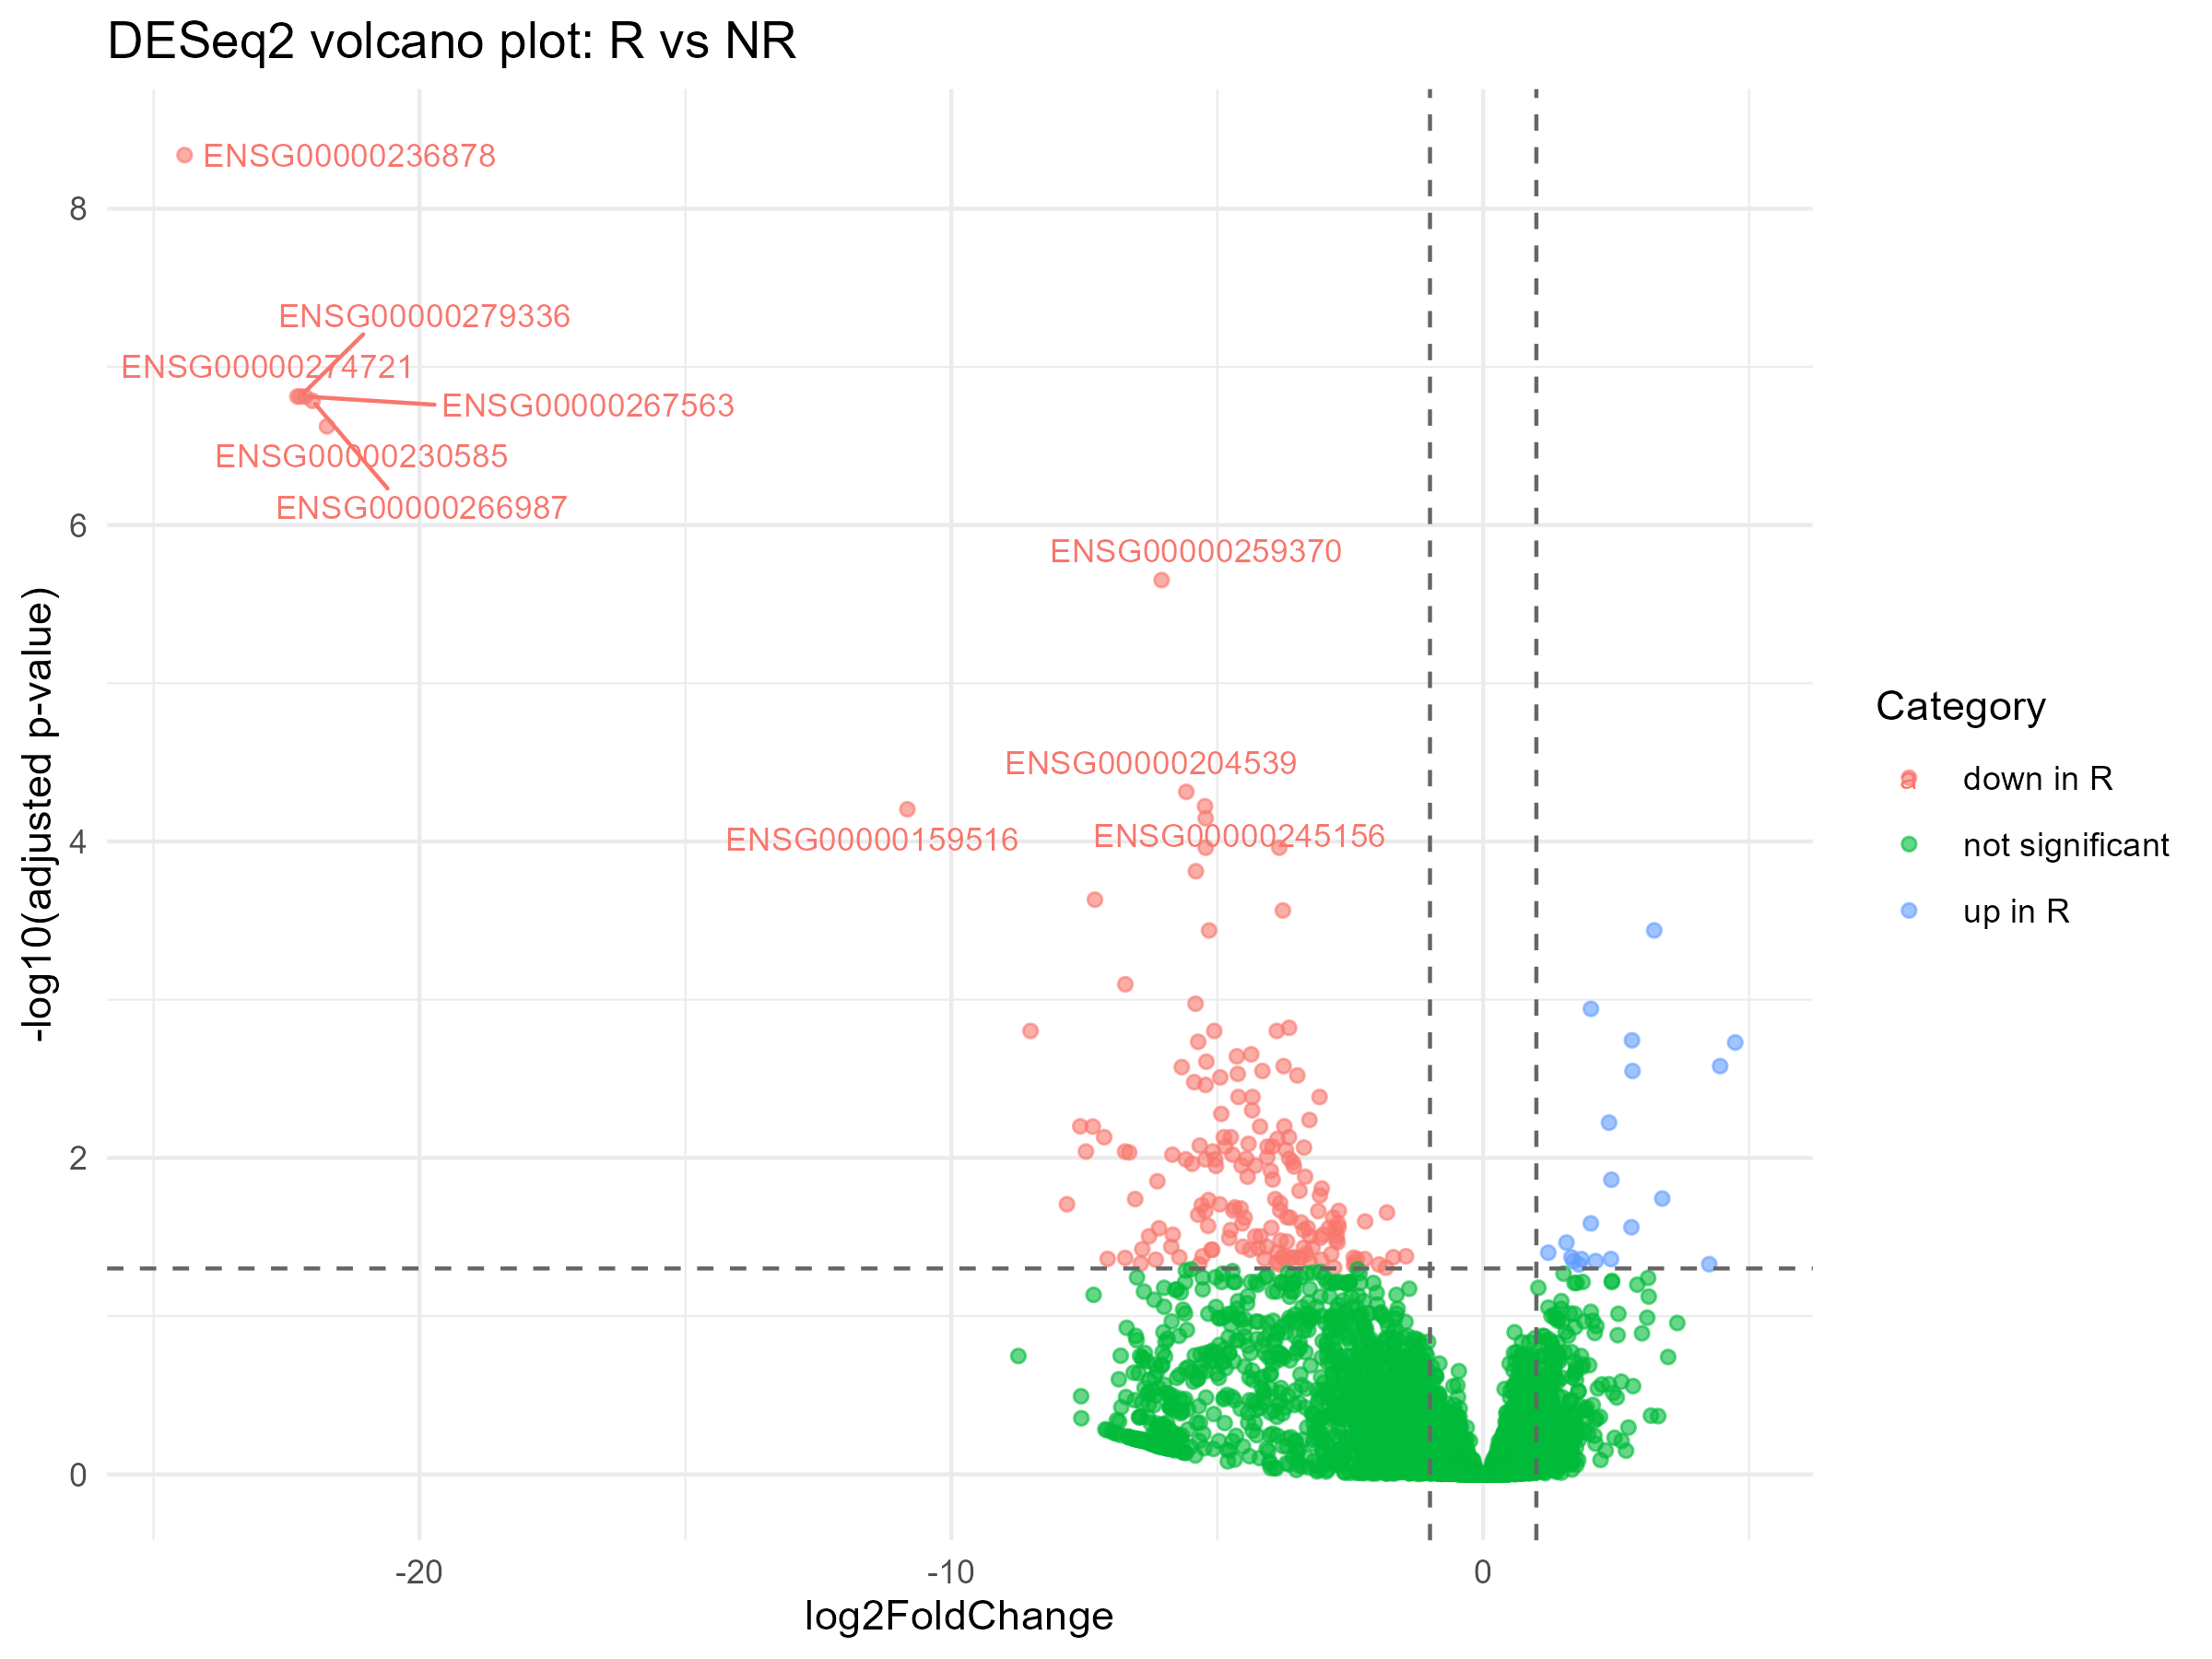

In [10]:
display(Image(filename="figures/03_deseq2_volcano_R_vs_NR.png", width=750))

## Вывод по DESeq2

После анализа DESeq2 была получена таблица из 41371 гена. Для отбора значимых генов использовался критерий `padj < 0.05` и `|log2FoldChange| >= 1`. По этому критерию значимыми оказались 190 генов.

На volcano plot видно, что большая часть генов не проходит выбранные пороги значимости и изменения экспрессии. Значимые гены распределены несимметрично: заметная часть наиболее значимых точек находится слева, то есть имеет отрицательный `log2FoldChange`. Это означает, что для этих генов экспрессия ниже в группе `R` по сравнению с `NR`.

При построении volcano plot были исключены строки, для которых `padj` оказался `NA`. Такие значения могут появляться, например, из-за независимой фильтрации низкоэкспрессируемых генов в DESeq2.

## Анализ дифференциальной экспрессии с помощью LIMMA

Во второй части работы проводится анализ дифференциальной экспрессии с помощью LIMMA. В отличие от DESeq2, который используется для RNA-seq counts, LIMMA изначально разрабатывался для анализа микрочипов и использует линейные модели.

В этой части используются данные из `GSE63885`: матрица экспрессии и таблица аннотации образцов. Для отбора значимых генов использовались обычное `P.Value < 0.05` и пороги по модулю `logFC`. Нужно проверить разные пороги logFC: 1, 2 и 3, сравнить количество значимых генов и выбрать наиболее подходящий порог для дальнейшего анализа. 

В качестве групп для сравнения используются значения `pCR` и `pNC` из клинической аннотации. В выбранной колонке аннотации группы распределены неравномерно: `pCR = 39` и `pNC = 2`, это нужно учитывать.

In [11]:
limma_results = pd.read_csv("results/limma_results_all.tsv", sep="\t")
limma_summary = pd.read_csv("results/limma_summary_logFC_thresholds.tsv", sep="\t")

print("Размер полной таблицы LIMMA:", limma_results.shape)

print("\nКоличество значимых генов при разных порогах logFC:")
display(limma_summary)

print("\nПервые 10 строк LIMMA результата:")
display(limma_results.head(10))

Размер полной таблицы LIMMA: (7588, 10)

Количество значимых генов при разных порогах logFC:


,logFC_threshold,significant_genes
0,1,67
1,2,4
2,3,0



Первые 10 строк LIMMA результата:


,logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene.Symbol,significant_logFC_1,significant_logFC_2,significant_logFC_3
0,0.737513,8.430347,4.354984,0.000081,0.353827,-0.569280,ZSCAN18,no,no,no
1,-1.074808,6.970136,-4.311937,0.000093,0.353827,-0.637496,MYOM1,yes,no,no
2,-0.670027,6.888196,-4.065375,0.000201,0.509022,-1.026600,CDC14B,no,no,no
3,-1.074529,8.819765,-3.852655,0.000386,0.546576,-1.359004,CTSC,yes,no,no
4,-1.485898,9.676106,-3.795390,0.000459,0.546576,-1.447786,SUPT16H,yes,no,no
5,-0.637371,8.525479,-3.788841,0.000468,0.546576,-1.457918,TUBA3C,no,no,no
6,-0.735790,6.610824,-3.763794,0.000504,0.546576,-1.496623,SREK1,no,no,no
7,-0.938353,12.696659,-3.616409,0.000782,0.666113,-1.722892,KRT18,no,no,no
8,1.626014,8.769851,3.599486,0.000822,0.666113,-1.748697,BTG3,yes,no,no
9,-1.054841,9.524526,-3.572806,0.000889,0.666113,-1.789300,PON2,yes,no,no


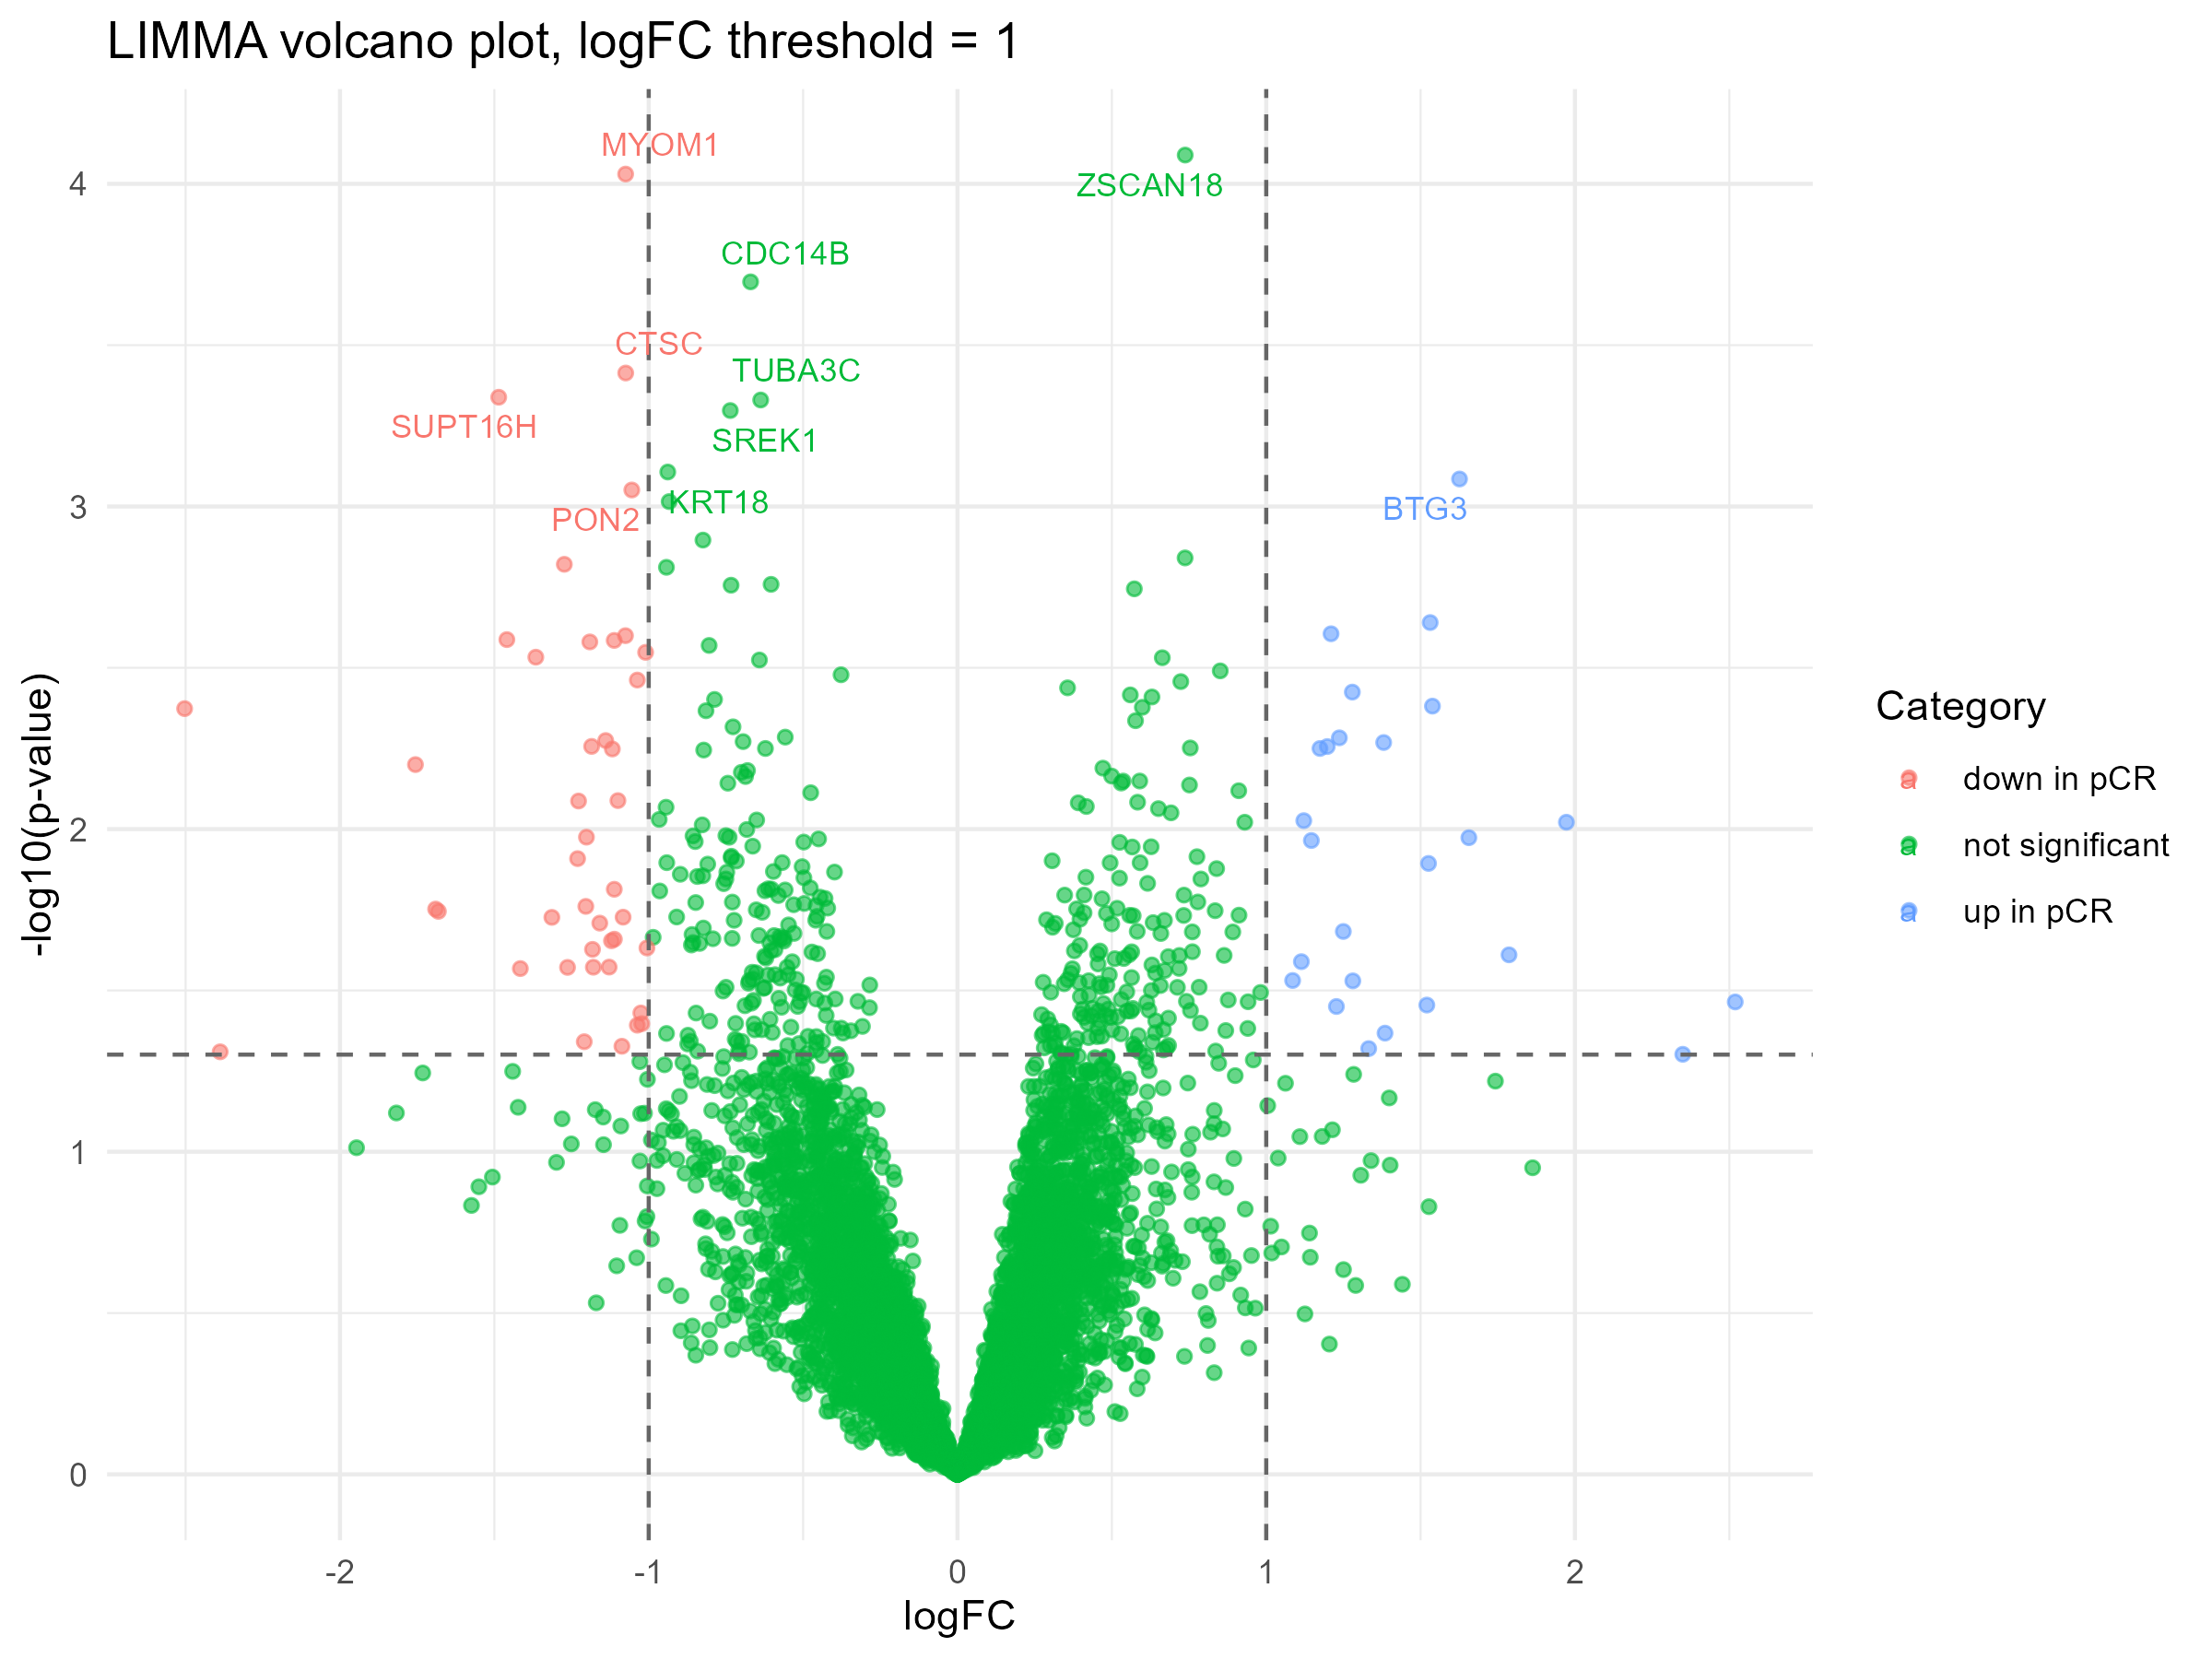

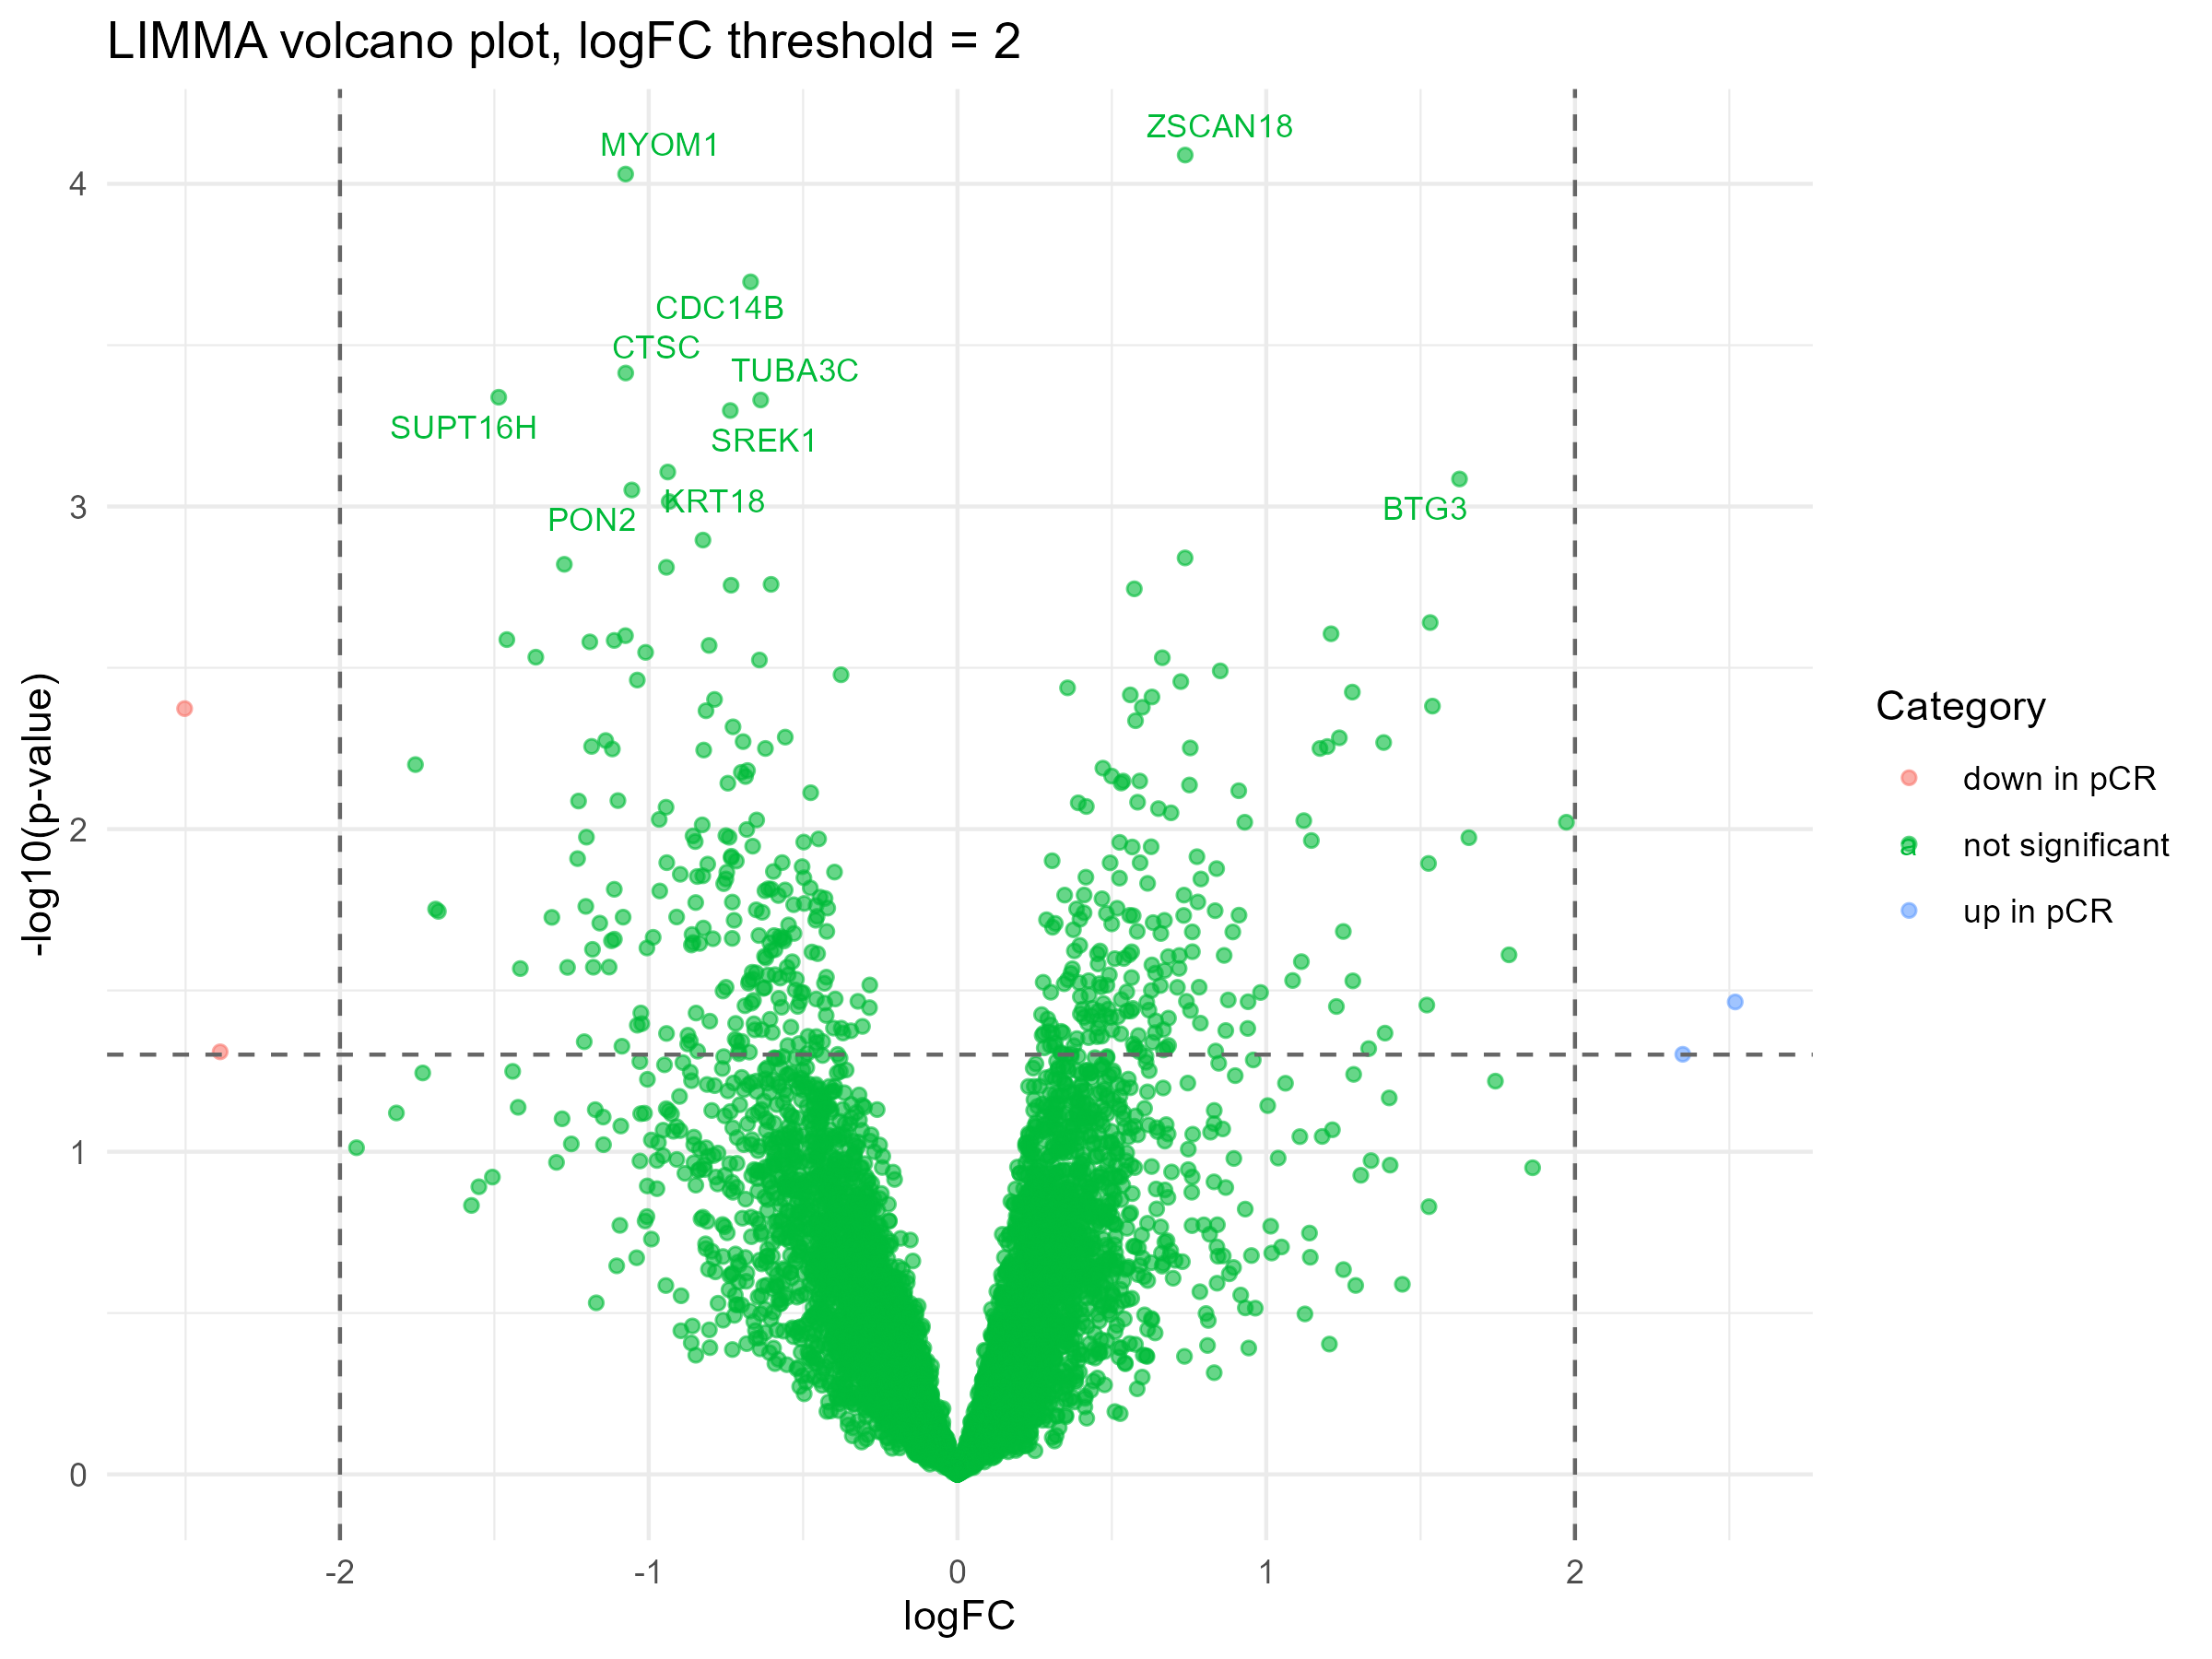

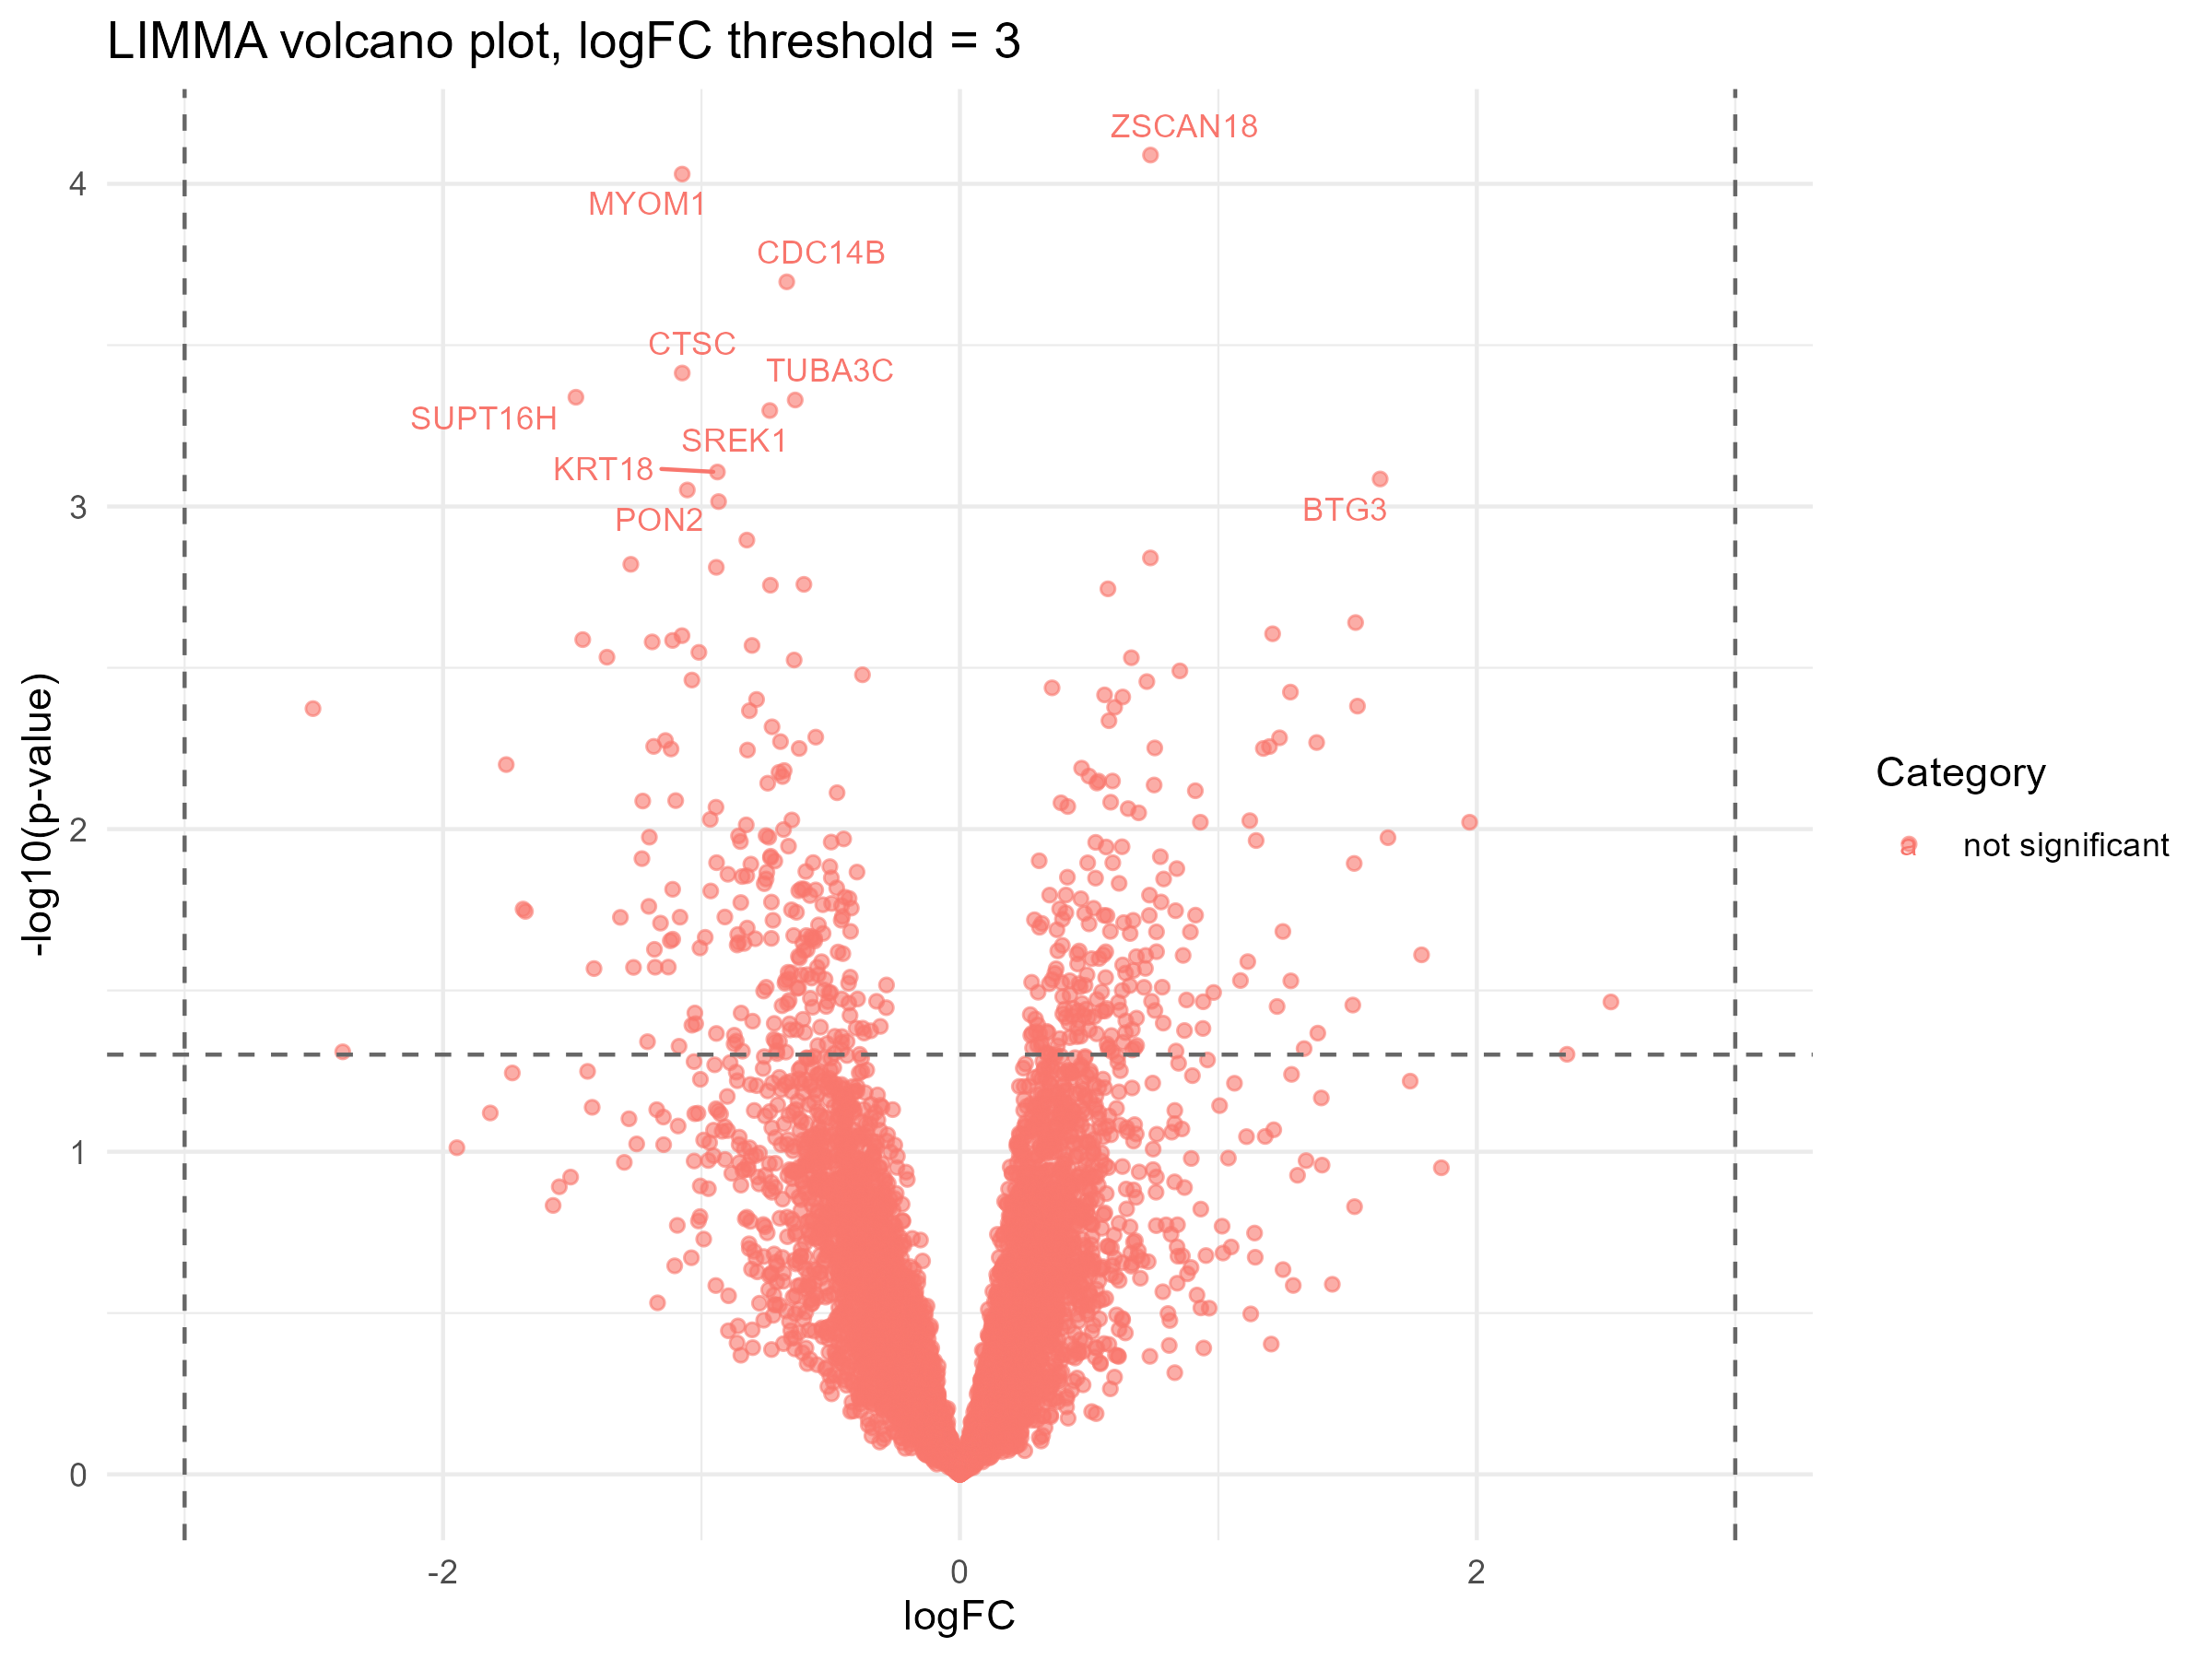

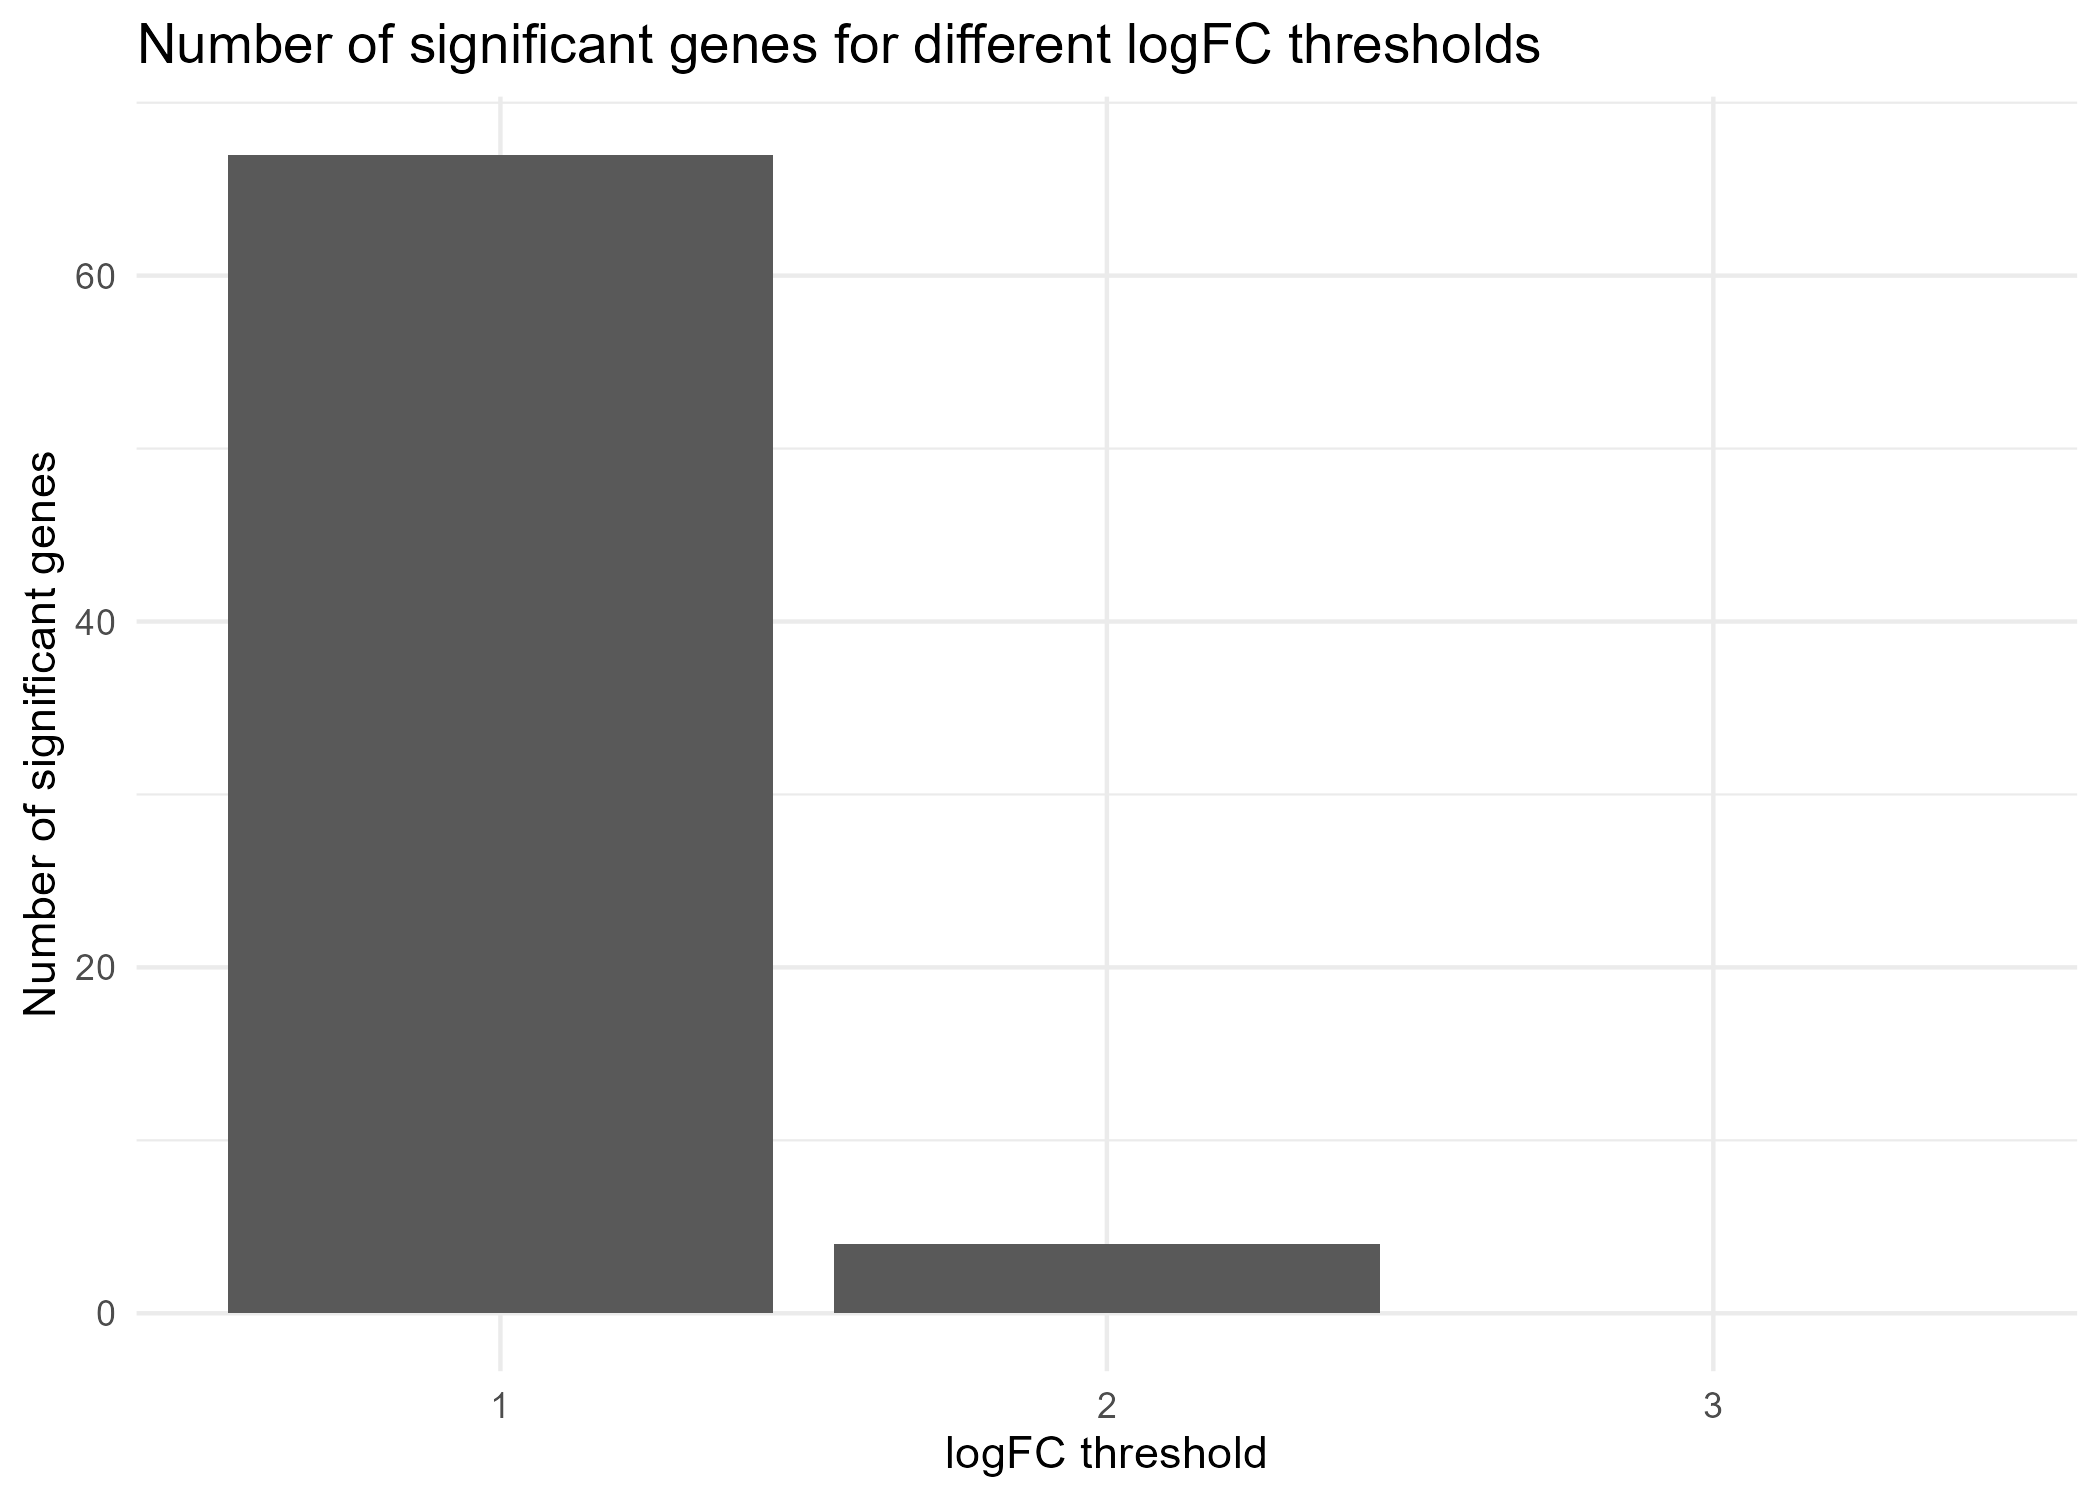

In [12]:
display(Image(filename="figures/04_limma_volcano_logFC1.png", width=600))
display(Image(filename="figures/05_limma_volcano_logFC2.png", width=600))
display(Image(filename="figures/06_limma_volcano_logFC3.png", width=600))
display(Image(filename="figures/07_limma_significant_counts_by_logFC.png", width=600))

### Вывод по LIMMA

В LIMMA-анализе гены отбирались по выбранному критерию: `P.Value < 0.05` и порог по модулю `logFC`. При пороге `logFC = 1` этот критерий прошли 67 генов, при пороге `logFC = 2` — 4 гена, а при пороге `logFC = 3` таких генов не осталось.

Это видно и по volcano plot: при `logFC = 1` часть точек проходит одновременно порог по p-value и порог по изменению экспрессии. При увеличении порога до `logFC = 2` таких точек становится заметно меньше, а при `logFC = 3` они исчезают. Поэтому более строгий порог резко сокращает список генов-кандидатов.

В выбранной колонке аннотации группы распределены неравномерно: `pCR = 39` и `pNC = 2`. Это может влиять на устойчивость статистического сравнения, потому что одна из групп содержит очень мало образцов.

Для дальнейшего анализа наиболее разумно выбрать порог `logFC = 1`. Он остаётся достаточно строгим, потому что требует и `P.Value < 0.05`, и заметного изменения экспрессии, но при этом оставляет 67 генов для интерпретации. Пороги `logFC = 2` и `logFC = 3` в этом наборе данных слишком сильно ужесточают отбор.

## Общий вывод

В первой части работы был проведён анализ RNA-seq данных LuC с помощью DESeq2. Сначала данные были подготовлены: были сопоставлены образцы из таблицы counts и metadata, удалены образцы без информации о группе, после чего были построены PCA и clustermap для оценки структуры данных. Затем был выполнен анализ дифференциальной экспрессии между группами `R` и `NR`, получена таблица результатов и построен volcano plot.

Во второй части был проведён анализ данных `GSE63885` с помощью LIMMA. Для этого использовалась матрица экспрессии микрочипового эксперимента и таблица аннотации образцов. Были проверены разные пороги по модулю `logFC`: 1, 2 и 3. При критерии `P.Value < 0.05` и пороге `logFC = 1` было найдено 67 генов, при пороге `logFC = 2` — 4 гена, а при пороге `logFC = 3` гены уже не проходили выбранный критерий.

По результатам LIMMA наиболее разумным порогом для дальнейшего анализа является `logFC = 1`, потому что он оставляет достаточно генов для интерпретации и при этом требует заметного изменения экспрессии. Более строгие пороги `logFC = 2` и `logFC = 3` слишком сильно сокращают список генов-кандидатов.

Таким образом, был проведён полный путь анализа дифференциальной экспрессии: от подготовки таблиц и визуализации структуры образцов до получения таблиц значимых генов и интерпретации результатов.